# Лабораторная работа №3: временные ряды
**Вариант:** 21



## 0. Подготовка


In [19]:
import os
import math
import zipfile
import urllib.request
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from IPython.display import display

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

ISU = 474321
VARIANT = ISU % 60
if VARIANT == 0:
    VARIANT = 60

print(f"ИСУ: {ISU}")
print(f"Вариант: {VARIANT}")

ИСУ: 474321
Вариант: 21


## 1. Загрузка и подготовка данных `sell.csv`

Наша заметка: Особенность файла: он сохранён в кодировке `cp1251`, разделитель — `;`, а десятичные числа записаны через запятую. Поэтому данные читаются не стандартной командой `pd.read_csv('sell.csv')`, а с правильными параметрами

In [2]:
def find_or_upload_csv(filename="sell.csv"):
    possible_paths = [
        filename,
        f"/content/{filename}",
        f"/mnt/data/{filename}",  # нужно только при локальной проверке в этой среде
    ]

    for path in possible_paths:
        if os.path.exists(path):
            print(f"Файл найден: {path}")
            return path

    # Если работаем в Google Colab и файл не найден
    try:
        from google.colab import files
        print("Файл sell.csv не найден. Загрузите его через появившееся окно.")
        uploaded = files.upload()
        if filename in uploaded:
            return filename

        csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
        if csv_files:
            print(f"Использую загруженный CSV-файл: {csv_files[0]}")
            return csv_files[0]

    except Exception as error:
        print("Автоматическая загрузка через Colab недоступна:", error)

    raise FileNotFoundError(
        "Не найден sell.csv. Загрузите файл в Colab и запустите ячейку ещё раз."
    )


def to_number(series):
    """Преобразует значения с запятой в десятичной части в числа."""
    return pd.to_numeric(
        series.astype(str)
        .str.replace("\xa0", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce"
    )


def extract_variant_data(path, variant):
    """
    Из общего файла вытаскивает блок нужного варианта.
    В каждом варианте 6 столбцов:
    мыло, порошок, средство, краска, пена, прибыль.
    """
    raw = pd.read_csv(path, encoding="cp1251", sep=";")

    # Вариант 1 начинается со столбца 1.
    # Каждый вариант занимает 6 столбцов.
    start_col = 1 + (variant - 1) * 6
    end_col = start_col + 6

    product_names = raw.iloc[0, start_col:end_col].astype(str).str.strip().tolist()

    data = raw.iloc[2:, [0] + list(range(start_col, end_col))].copy()
    data.columns = ["day"] + product_names

    for col in data.columns:
        data[col] = to_number(data[col])

    data = data.dropna(subset=["day"]).reset_index(drop=True)
    data["day"] = data["day"].astype(int)

    return data


csv_path = find_or_upload_csv("sell.csv")
df = extract_variant_data(csv_path, VARIANT)

print("Размер данных:", df.shape)
display(df.head())
display(df.tail())

Файл sell.csv не найден. Загрузите его через появившееся окно.


Saving sell.csv to sell.csv
Размер данных: (50, 7)


,day,мыло,порошок,средство,краска,пена,прибыль
0,1,71,20,19,44,19,26.418
1,2,101,16,20,46,19,29.583
2,3,87,27,19,44,18,25.868
3,4,92,17,20,42,20,28.389
4,5,86,16,20,41,16,26.939


,day,мыло,порошок,средство,краска,пена,прибыль
45,46,74,14,19,41,20,24.039
46,47,124,19,26,44,18,31.368
47,48,95,18,20,46,21,27.985
48,49,125,21,22,44,19,29.555
49,50,76,17,19,40,19,26.279


## 2. Первичный график временных рядов

Здесь смотрим исходные продажи товаров и прибыль по дням. По оси X — день продаж, по оси Y — значение показателя.

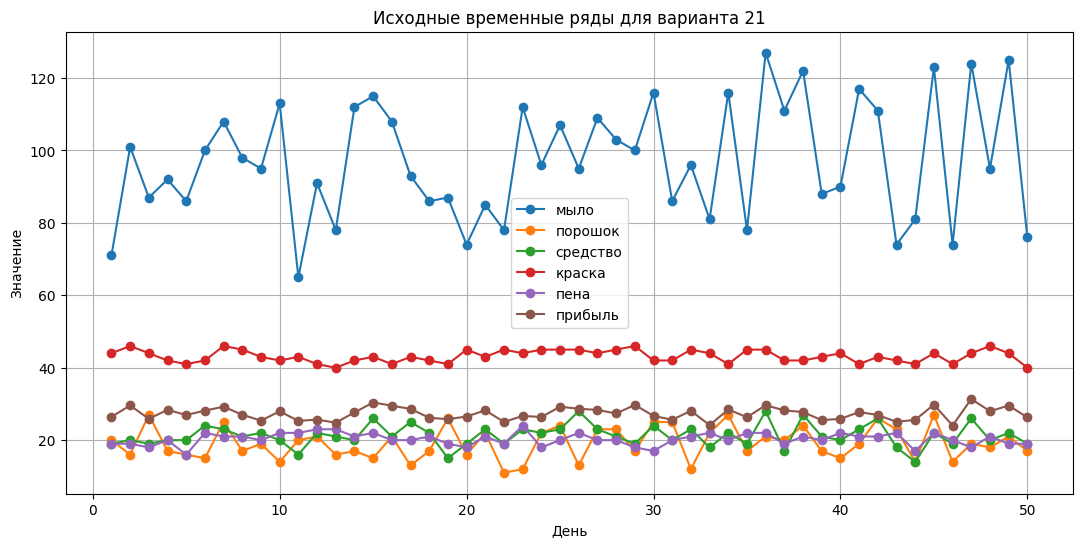

In [3]:
plt.figure(figsize=(13, 6))

for col in df.columns:
    if col != "day":
        plt.plot(df["day"], df[col], marker="o", linewidth=1.5, label=col)

plt.title(f"Исходные временные ряды для варианта {VARIANT}")
plt.xlabel("День")
plt.ylabel("Значение")
plt.legend()
plt.show()

исходные временные ряды содержат колебания и шумы,
при этом показатель «мыло» имеет самые большие изменения по значениям.
Прибыль изменяется более стабильно и без резких скачков по сравнению с остальными показателями.

## 3. Реализация методов фильтрации

(Фильтрация нужна, чтобы сгладить случайные колебания и увидеть более общий тренд.)

В работе реализованы:

1. **Скользящее среднее** — заменяет значение средним по соседним точкам.
2. **Фильтр Калмана** — последовательно уточняет оценку состояния ряда, учитывая шум измерений.
3. **Фильтр Савицкого–Голея** — сглаживает ряд полиномом на локальном окне.
4. **Вейвлет-фильтрация Хаара** — раскладывает ряд на низкочастотную и высокочастотную части, затем подавляет мелкий шум.

In [4]:
def fill_series(x):
    """Заполняет пропуски, чтобы фильтры могли работать корректно."""
    return (
        pd.Series(x)
        .astype(float)
        .interpolate(limit_direction="both")
        .bfill()
        .ffill()
        .to_numpy()
    )


def moving_average(x, window=5):
    """Скользящее среднее."""
    x = fill_series(x)
    return pd.Series(x).rolling(window=window, center=True, min_periods=1).mean().to_numpy()


def kalman_filter_1d(z, process_variance=None, measurement_variance=None):
    """
    Простой одномерный фильтр Калмана.
    Модель: истинное значение меняется медленно, измерения содержат шум.
    """
    z = fill_series(z)
    n = len(z)

    if measurement_variance is None:
        diff_var = np.nanvar(np.diff(z))
        measurement_variance = max(diff_var, 1e-6)

    if process_variance is None:
        process_variance = max(measurement_variance * 0.05, 1e-6)

    x_est = np.zeros(n)
    p_est = np.zeros(n)

    x_est[0] = z[0]
    p_est[0] = 1.0

    for k in range(1, n):
        # prediction
        x_pred = x_est[k - 1]
        p_pred = p_est[k - 1] + process_variance

        # update
        kalman_gain = p_pred / (p_pred + measurement_variance)
        x_est[k] = x_pred + kalman_gain * (z[k] - x_pred)
        p_est[k] = (1 - kalman_gain) * p_pred

    return x_est


def savgol_smoothing(x, window=7, polyorder=2):
    """Фильтр Савицкого–Голея."""
    x = fill_series(x)
    n = len(x)

    # Окно должно быть нечётным и не больше длины ряда
    if window > n:
        window = n if n % 2 == 1 else n - 1
    if window % 2 == 0:
        window -= 1
    if window <= polyorder:
        return x.copy()

    return savgol_filter(x, window_length=window, polyorder=polyorder, mode="interp")


def next_power_of_two(n):
    return 1 << (n - 1).bit_length()


def haar_wavelet_denoise(x, threshold_scale=0.8):
    """
    Вейвлет-фильтрация Хаара.
    Ряд раскладывается на approximation/detail коэффициенты.
    Малые detail-коэффициенты обнуляются как шум.
    """
    x = fill_series(x)
    original_len = len(x)

    padded_len = next_power_of_two(original_len)
    current = np.pad(x, (0, padded_len - original_len), mode="edge").astype(float)

    details = []

    # Прямое преобразование Хаара
    while len(current) > 1:
        avg = (current[0::2] + current[1::2]) / np.sqrt(2)
        detail = (current[0::2] - current[1::2]) / np.sqrt(2)
        details.append(detail)
        current = avg

    # Порог для подавления шума
    all_details = np.concatenate(details)
    sigma = np.median(np.abs(all_details - np.median(all_details))) / 0.6745
    threshold = threshold_scale * sigma * np.sqrt(2 * np.log(padded_len))

    filtered_details = [
        np.where(np.abs(detail) < threshold, 0, detail)
        for detail in details
    ]

    # Обратное преобразование Хаара
    reconstructed = current
    for detail in filtered_details[::-1]:
        avg = reconstructed
        restored = np.empty(avg.size * 2)
        restored[0::2] = (avg + detail) / np.sqrt(2)
        restored[1::2] = (avg - detail) / np.sqrt(2)
        reconstructed = restored

    return reconstructed[:original_len]


def apply_all_filters(series):
    return pd.DataFrame({
        "исходный ряд": fill_series(series),
        "скользящее среднее": moving_average(series, window=5),
        "Калман": kalman_filter_1d(series),
        "Савицкий–Голей": savgol_smoothing(series, window=7, polyorder=2),
        "вейвлет Хаара": haar_wavelet_denoise(series, threshold_scale=0.8),
    })


print("Функции фильтрации готовы.")

Функции фильтрации готовы.


## 4. Сравнение фильтров на прибыли

Прибыль удобно брать как главный итоговый показатель, потому что она зависит от продаж разных товаров.

,day,исходный ряд,скользящее среднее,Калман,Савицкий–Голей,вейвлет Хаара
0,1,26.418,27.289667,26.418000,27.458571,27.090078
1,2,29.583,27.564500,26.949263,27.321786,27.090078
2,3,25.868,27.439400,26.755842,27.335071,27.090078
3,4,28.389,27.786800,27.060024,27.498429,27.090078
4,5,26.939,27.717800,27.036896,27.617667,27.090078


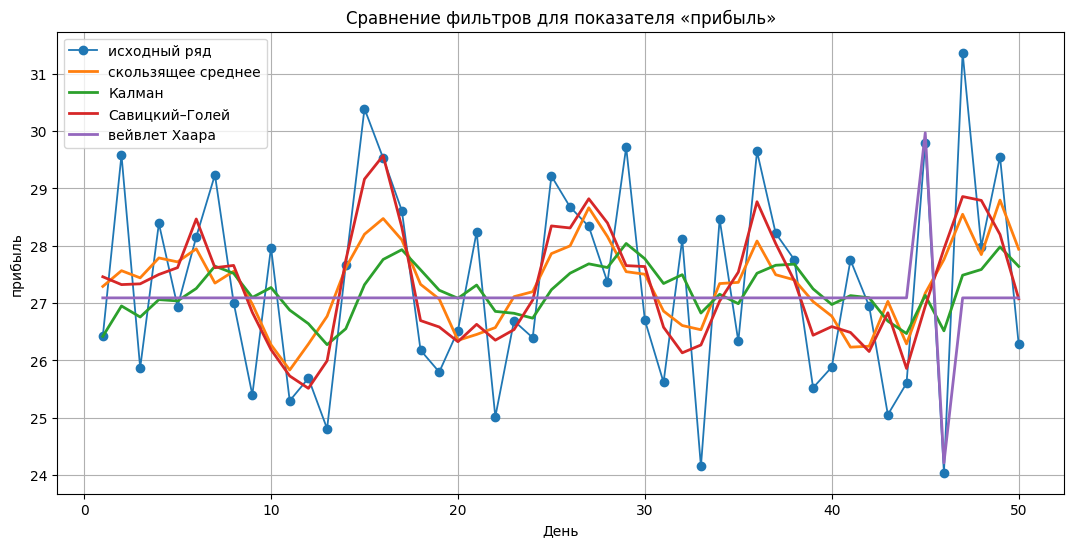

In [5]:
target_col = "прибыль"

filtered_profit = apply_all_filters(df[target_col])
filtered_profit.insert(0, "day", df["day"])

display(filtered_profit.head())

plt.figure(figsize=(13, 6))
plt.plot(filtered_profit["day"], filtered_profit["исходный ряд"], marker="o", linewidth=1.3, label="исходный ряд")

for method in ["скользящее среднее", "Калман", "Савицкий–Голей", "вейвлет Хаара"]:
    plt.plot(filtered_profit["day"], filtered_profit[method], linewidth=2, label=method)

plt.title(f"Сравнение фильтров для показателя «{target_col}»")
plt.xlabel("День")
plt.ylabel(target_col)
plt.legend()
plt.show()

Вывод:
После фильтрации ряд прибыли стал более плавным и менее шумным.
Скользящее среднее и фильтр Калмана хорошо сглаживают колебания,
а фильтр Савицкого–Голея лучше сохраняет локальные изменения и пики.

## 5. Численное сравнение фильтров

Сравним фильтры по двум простым характеристикам:

- **Среднее абсолютное отклонение от исходного ряда** — насколько сильно фильтр изменил данные.
- **Шероховатость** — стандартное отклонение разностей соседних точек. Чем ниже, тем более гладкий ряд.

но самый гладкий фильтр не всегда лучший, потому что он может слишком сильно искажать реальные изменения.

In [6]:
def roughness(x):
    x = fill_series(x)
    return np.std(np.diff(x))


metrics = []

original = filtered_profit["исходный ряд"].to_numpy()

for method in ["скользящее среднее", "Калман", "Савицкий–Голей", "вейвлет Хаара"]:
    y = filtered_profit[method].to_numpy()

    metrics.append({
        "метод": method,
        "среднее абсолютное отклонение": np.mean(np.abs(original - y)),
        "шероховатость": roughness(y),
        "снижение шероховатости, %": (1 - roughness(y) / roughness(original)) * 100
    })

metrics_df = pd.DataFrame(metrics).sort_values("шероховатость")
display(metrics_df)

,метод,среднее абсолютное отклонение,шероховатость,"снижение шероховатости, %"
1,Калман,1.252049,0.373483,85.452629
0,скользящее среднее,1.217486,0.534453,79.182761
2,Савицкий–Голей,1.073176,0.749007,70.825744
3,вейвлет Хаара,1.363623,1.007790,60.745996


Вывод:
Фильтр Калмана показал наименьшую шероховатость,
то есть обеспечил самое сильное сглаживание временного ряда.
Фильтр Савицкого–Голея меньше остальных отклоняется от исходных данных,
поэтому лучше сохраняет реальные изменения сигнала.

## 6. Фильтрация всех показателей варианта

Ниже строятся графики по каждому показателю: исходный ряд и несколько вариантов сглаживания.

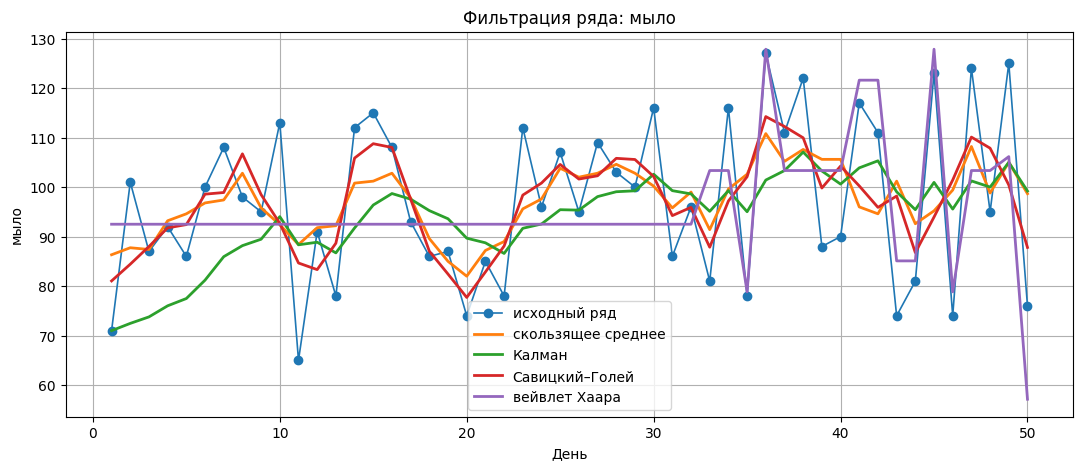

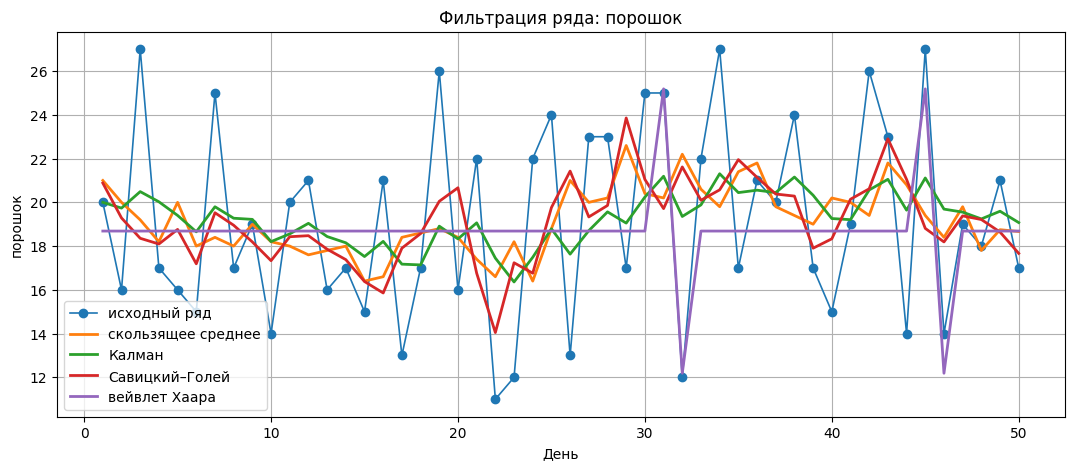

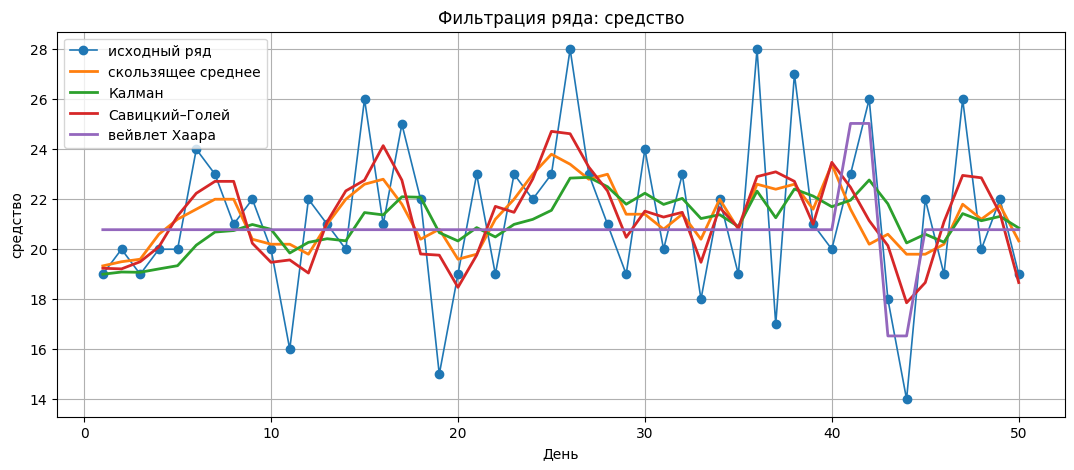

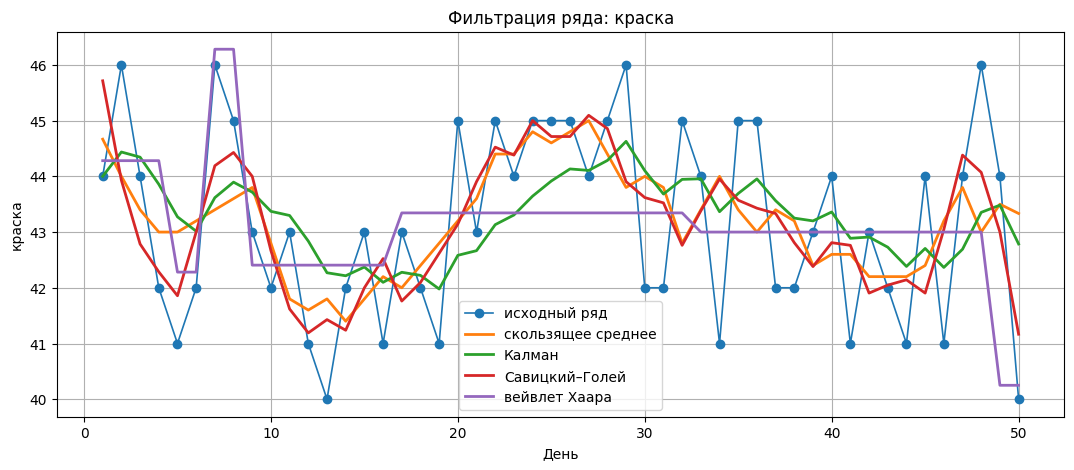

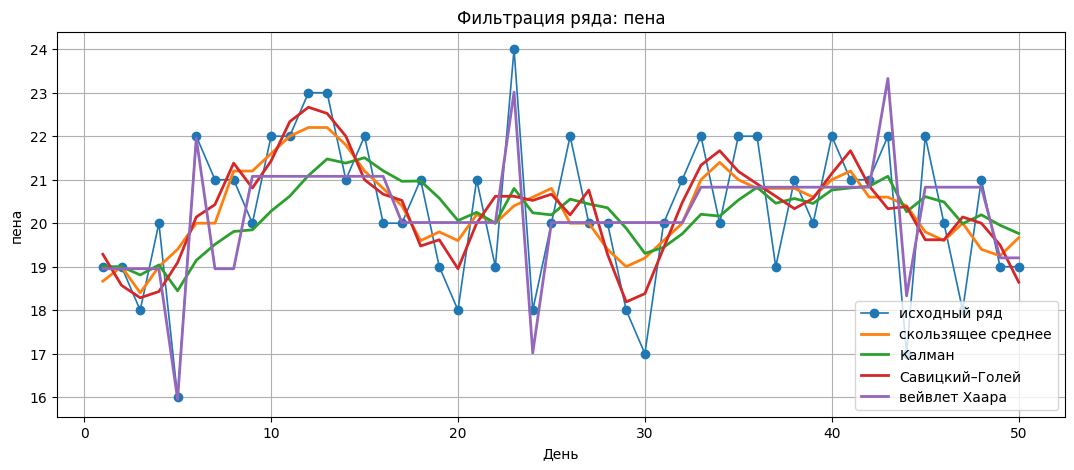

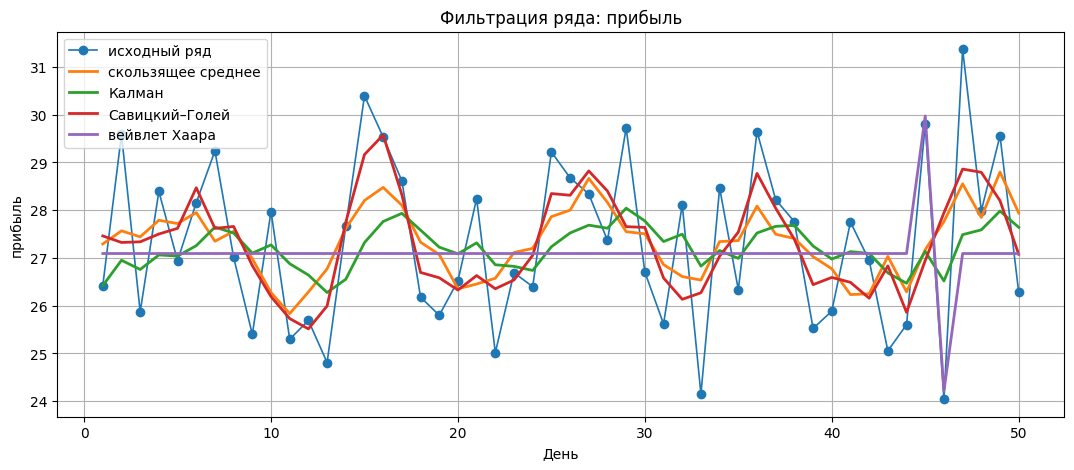

In [7]:
for col in df.columns:
    if col == "day":
        continue

    filtered = apply_all_filters(df[col])
    filtered.insert(0, "day", df["day"])

    plt.figure(figsize=(13, 5))
    plt.plot(filtered["day"], filtered["исходный ряд"], marker="o", linewidth=1.2, label="исходный ряд")
    plt.plot(filtered["day"], filtered["скользящее среднее"], linewidth=2, label="скользящее среднее")
    plt.plot(filtered["day"], filtered["Калман"], linewidth=2, label="Калман")
    plt.plot(filtered["day"], filtered["Савицкий–Голей"], linewidth=2, label="Савицкий–Голей")
    plt.plot(filtered["day"], filtered["вейвлет Хаара"], linewidth=2, label="вейвлет Хаара")

    plt.title(f"Фильтрация ряда: {col}")
    plt.xlabel("День")
    plt.ylabel(col)
    plt.legend()
    plt.show()

Все методы фильтрации уменьшают шум и делают временные ряды более плавными.
Фильтр Калмана обеспечивает наиболее сильное сглаживание,
а фильтр Савицкого–Голея лучше сохраняет форму и локальные изменения исходных данных.
Вейвлет Хаара заметно упрощает сигнал и делает его более ступенчатым.

## 7. Анализ данных

Здесь считаются характеристики временных рядов: средние значения, разброс, корреляции, автокорреляция и периодичность.

In [8]:
print("Описательные статистики:")
display(df.describe().T)

print("\nКоличество пропусков:")
display(df.isna().sum())

Описательные статистики:


,count,mean,std,min,25%,50%,75%,max
day,50.0,25.50000,14.577380,1.000,13.25000,25.5000,37.75000,50.000
мыло,50.0,97.12000,16.329065,65.000,86.00000,95.5000,111.00000,127.000
порошок,50.0,19.16000,4.441732,11.000,16.00000,19.0000,22.75000,27.000
средство,50.0,21.28000,3.057543,14.000,19.00000,21.0000,23.00000,28.000
краска,50.0,43.18000,1.710591,40.000,42.00000,43.0000,45.00000,46.000
пена,50.0,20.30000,1.717259,16.000,19.00000,20.0000,22.00000,24.000
прибыль,50.0,27.31718,1.733236,24.039,25.87175,27.1865,28.44375,31.368



Количество пропусков:


,0
day,0
мыло,0
порошок,0
средство,0
краска,0
пена,0
прибыль,0


Наибольший разброс значений наблюдается у показателя «мыло»,
а прибыль изменяется более стабильно по сравнению с остальными показателями.

### 7.1. Корреляции

(Корреляция показывает, насколько показатели связаны между собой)
Значение ближе к `1` означает сильную прямую связь, ближе к `-1` — обратную связь, около `0` — слабую линейную связь

,мыло,порошок,средство,краска,пена,прибыль
мыло,1.000000,0.270416,0.622266,0.124148,0.075836,0.738307
порошок,0.270416,1.000000,0.043218,-0.049530,-0.110768,0.071828
средство,0.622266,0.043218,1.000000,0.189168,0.282961,0.539850
краска,0.124148,-0.049530,0.189168,1.000000,0.009032,0.328944
пена,0.075836,-0.110768,0.282961,0.009032,1.000000,-0.049510
прибыль,0.738307,0.071828,0.539850,0.328944,-0.049510,1.000000


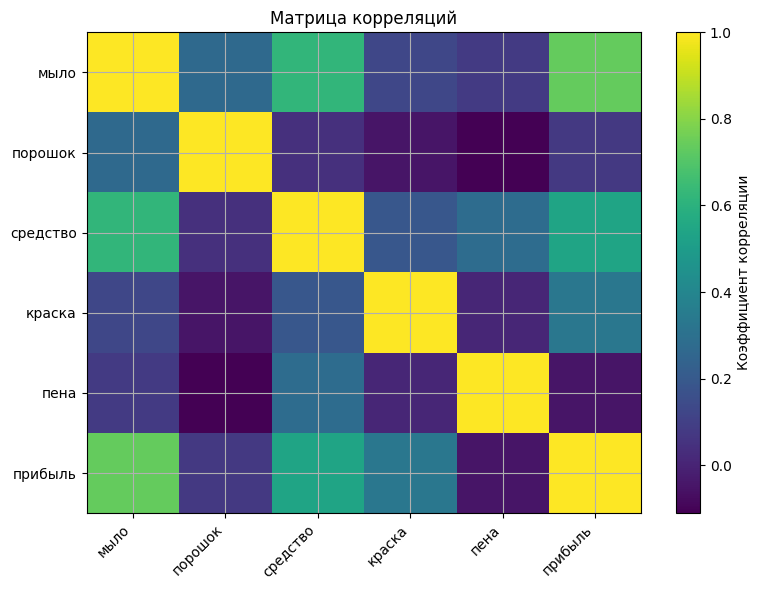

Связь товаров с прибылью:


,прибыль
мыло,0.738307
средство,0.539850
краска,0.328944
порошок,0.071828
пена,-0.049510


In [9]:
corr = df.drop(columns=["day"]).corr()

display(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Коэффициент корреляции")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Матрица корреляций")
plt.tight_layout()
plt.show()

profit_corr = corr["прибыль"].drop("прибыль").sort_values(ascending=False)
print("Связь товаров с прибылью:")
display(profit_corr)

Наибольшая положительная связь с прибылью наблюдается у показателя «мыло»,
а также у показателя «средство».
Показатели «порошок» и «пена» имеют слабую корреляцию с прибылью,
что говорит о меньшем влиянии этих товаров на общий результат

### 7.2. Автокорреляция прибыли

Автокорреляция показывает, похож ли ряд сам на себя при сдвиге на несколько дней.
Заметка: Если на каком-то лаге значение высокое, это может указывать на повторяемость или периодичность

,lag,autocorrelation
0,1,-0.104270
1,2,0.184613
2,3,-0.266848
3,4,-0.103516
4,5,-0.222119
5,6,-0.200935
6,7,-0.178288
7,8,-0.026687
8,9,0.190558
9,10,0.087986


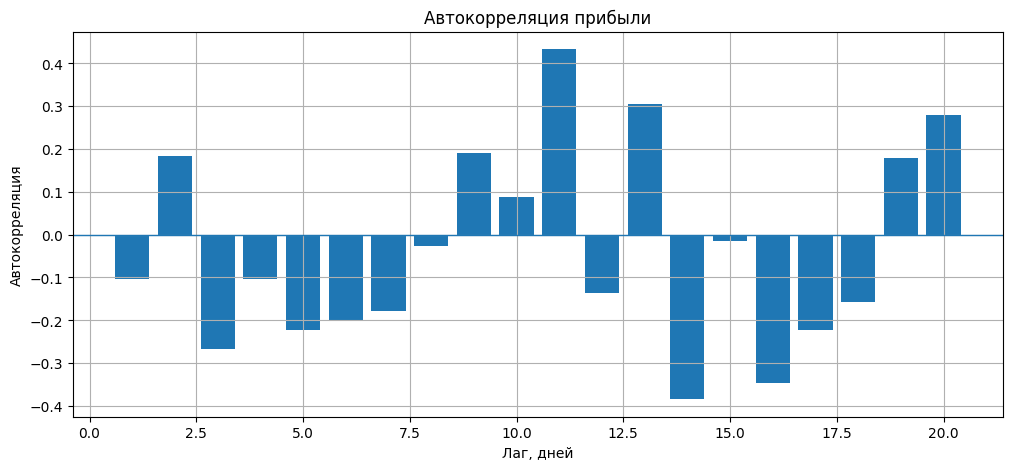

In [10]:
def autocorrelation_values(x, max_lag=20):
    s = pd.Series(fill_series(x))
    result = []
    for lag in range(1, max_lag + 1):
        result.append({
            "lag": lag,
            "autocorrelation": s.autocorr(lag=lag)
        })
    return pd.DataFrame(result)


acf_profit = autocorrelation_values(df["прибыль"], max_lag=20)
display(acf_profit)

plt.figure(figsize=(12, 5))
plt.bar(acf_profit["lag"], acf_profit["autocorrelation"])
plt.axhline(0, linewidth=1)
plt.title("Автокорреляция прибыли")
plt.xlabel("Лаг, дней")
plt.ylabel("Автокорреляция")
plt.show()

Автокорреляция прибыли показывает наличие зависимости между соседними значениями временного ряда.
Для некоторых лагов наблюдаются положительные коэффициенты корреляции,
что указывает на повторяющиеся колебания и возможную периодичность изменения прибыли.

### 7.3. Поиск возможной периодичности через FFT

FFT показывает, какие частоты сильнее всего выражены в ряду.  
Период считается как `1 / частота`

,ряд,"период, дней",мощность
0,мыло,2.173913,91696.738432
1,мыло,10.000000,43085.977049
2,мыло,3.846154,31326.036077
3,порошок,2.941176,4419.017484
4,порошок,2.000000,2704.000000
5,порошок,3.846154,2056.524847
6,средство,2.173913,1609.450906
7,средство,2.941176,1402.373214
8,средство,10.000000,1131.136581
9,краска,25.000000,637.566589


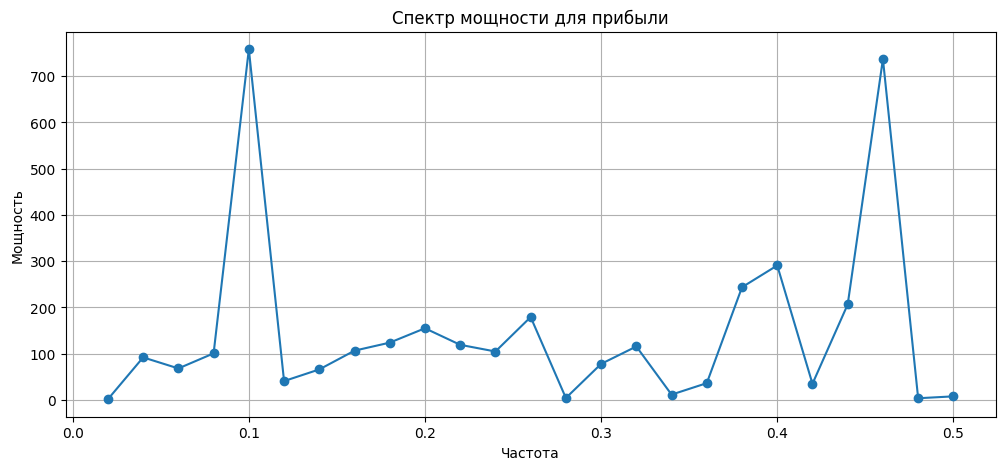

Наиболее выраженные периоды для прибыли:


,"период, дней",мощность
0,10.000000,757.839441
1,2.173913,736.744204
2,2.500000,290.600759
3,2.631579,243.579656
4,2.272727,206.387188


In [11]:
def dominant_periods(x, top_n=3):
    x = fill_series(x)
    x = x - np.mean(x)
    n = len(x)

    freq = np.fft.rfftfreq(n, d=1)
    power = np.abs(np.fft.rfft(x)) ** 2

    # Пропускаем нулевую частоту, она отвечает за средний уровень ряда
    indices = np.argsort(power[1:])[::-1] + 1

    rows = []
    for i in indices[:top_n]:
        if freq[i] == 0:
            continue
        rows.append({
            "период, дней": 1 / freq[i],
            "мощность": power[i]
        })

    return pd.DataFrame(rows)


period_rows = []

for col in df.columns:
    if col == "day":
        continue

    periods = dominant_periods(df[col], top_n=3)
    for _, row in periods.iterrows():
        period_rows.append({
            "ряд": col,
            "период, дней": row["период, дней"],
            "мощность": row["мощность"]
        })

period_df = pd.DataFrame(period_rows)
display(period_df)

profit_periods = dominant_periods(df["прибыль"], top_n=5)

plt.figure(figsize=(12, 5))
profit_values = fill_series(df["прибыль"])
profit_centered = profit_values - np.mean(profit_values)
freq = np.fft.rfftfreq(len(profit_centered), d=1)
power = np.abs(np.fft.rfft(profit_centered)) ** 2

plt.plot(freq[1:], power[1:], marker="o")
plt.title("Спектр мощности для прибыли")
plt.xlabel("Частота")
plt.ylabel("Мощность")
plt.show()

print("Наиболее выраженные периоды для прибыли:")
display(profit_periods)

На спектре мощности для прибыли наблюдаются выраженные пики,
что говорит о наличии периодических колебаний во временном ряду.
Наиболее заметный период составляет около 10 дней,
а также присутствуют более короткие циклы длительностью примерно 2–3 дня.

## 8. вывод по данным


In [12]:
main_product = profit_corr.index[0]
main_corr = profit_corr.iloc[0]

profit_mean = df["прибыль"].mean()
profit_std = df["прибыль"].std()
profit_min = df["прибыль"].min()
profit_max = df["прибыль"].max()

best_smooth = metrics_df.iloc[0]["метод"]

print("ВЫВОД ПО ОСНОВНЫМ ДАННЫМ")
print("-" * 70)
print(f"В варианте {VARIANT} анализировались продажи за {len(df)} дней.")
print(f"Средняя прибыль составила {profit_mean:.3f} тыс. руб.")
print(f"Минимальная прибыль: {profit_min:.3f} тыс. руб., максимальная: {profit_max:.3f} тыс. руб.")
print(f"Стандартное отклонение прибыли: {profit_std:.3f}, то есть прибыль колеблется, но без резких экстремальных выбросов.")
print(f"Сильнее всего с прибылью связан показатель «{main_product}»: корреляция {main_corr:.3f}.")
print(f"Самым гладким по метрике шероховатости оказался фильтр: {best_smooth}.")
print("Фильтр Савицкого–Голея хорошо сохраняет форму ряда, скользящее среднее проще всего объяснить,")
print("Калман последовательно сглаживает измерения, а вейвлет-фильтрация подавляет высокочастотный шум.")
print("По FFT можно оценить возможные периоды, но из-за небольшой длины ряда в 50 дней эти периоды нужно считать приблизительными.")

ВЫВОД ПО ОСНОВНЫМ ДАННЫМ
----------------------------------------------------------------------
Для ИСУ 474321 получен вариант 21.
В варианте 21 анализировались продажи за 50 дней.
Средняя прибыль составила 27.317 тыс. руб.
Минимальная прибыль: 24.039 тыс. руб., максимальная: 31.368 тыс. руб.
Стандартное отклонение прибыли: 1.733, то есть прибыль колеблется, но без резких экстремальных выбросов.
Сильнее всего с прибылью связан показатель «мыло»: корреляция 0.738.
Самым гладким по метрике шероховатости оказался фильтр: Калман.
Фильтр Савицкого–Голея хорошо сохраняет форму ряда, скользящее среднее проще всего объяснить,
Калман последовательно сглаживает измерения, а вейвлет-фильтрация подавляет высокочастотный шум.
По FFT можно оценить возможные периоды, но из-за небольшой длины ряда в 50 дней эти периоды нужно считать приблизительными.


# 9. Хард-свобода: внешний датасет с несколькими сенсорами

Для дополнительной части используется открытый датасет **UCI Air Quality**.  
Он содержит временные измерения качества воздуха и ответы нескольких сенсоров.

Что делаем:

1. Загружаем данные из интернета.
2. Берём несколько сенсорных рядов.
3. Строим графики.
4. Считаем корреляции.
5. Применяем фильтрацию.
6. Формулируем выводы.


In [13]:
AQ_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"

def load_air_quality_dataset():
    try:
        print("Пробую скачать UCI Air Quality dataset...")
        with urllib.request.urlopen(AQ_URL, timeout=60) as response:
            content = response.read()

        with zipfile.ZipFile(BytesIO(content)) as zf:
            with zf.open("AirQualityUCI.csv") as file:
                aq = pd.read_csv(
                    file,
                    sep=";",
                    decimal=",",
                    na_values=-200,
                    encoding="latin1"
                )

        aq = aq.dropna(how="all", axis=1).dropna(how="all")
        aq["Date_Time"] = pd.to_datetime(
            aq["Date"].astype(str) + " " + aq["Time"].astype(str),
            format="%d/%m/%Y %H.%M.%S",
            errors="coerce"
        )
        aq = aq.dropna(subset=["Date_Time"])
        source = "UCI Air Quality"

    except Exception as error:
        print("Не удалось скачать внешний датасет:", error)
        print("Создаю резервный учебный пример с двумя сенсорами.")

        rng = np.random.default_rng(42)
        n = 24 * 20
        t = np.arange(n)
        real_co = 2.0 + 0.8 * np.sin(2 * np.pi * t / 24) + 0.15 * np.sin(2 * np.pi * t / 7)
        sensor_1 = real_co * 320 + 950 + rng.normal(0, 45, n)
        sensor_2 = real_co * 280 + 830 + rng.normal(0, 55, n)

        aq = pd.DataFrame({
            "Date_Time": pd.date_range("2024-01-01", periods=n, freq="h"),
            "CO(GT)": real_co + rng.normal(0, 0.12, n),
            "PT08.S1(CO)": sensor_1,
            "PT08.S2(NMHC)": sensor_2,
            "T": 20 + 5 * np.sin(2 * np.pi * t / 24) + rng.normal(0, 0.8, n),
            "RH": 55 + 10 * np.cos(2 * np.pi * t / 24) + rng.normal(0, 2, n),
        })
        source = "резервная учебная версия"

    return aq, source


aq, aq_source = load_air_quality_dataset()
print("Источник данных:", aq_source)
print("Размер:", aq.shape)
display(aq.head())

Пробую скачать UCI Air Quality dataset...
Источник данных: UCI Air Quality
Размер: (9357, 16)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Date_Time
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00


In [14]:
needed_cols = ["Date_Time", "CO(GT)", "PT08.S1(CO)", "PT08.S2(NMHC)", "T", "RH"]
available_cols = [col for col in needed_cols if col in aq.columns]

aq_small = aq[available_cols].copy()

for col in aq_small.columns:
    if col != "Date_Time":
        aq_small[col] = pd.to_numeric(aq_small[col], errors="coerce")

aq_small = aq_small.dropna().head(500).reset_index(drop=True)

print("Данные для анализа:")
display(aq_small.head())
display(aq_small.describe().T)

Данные для анализа:


,Date_Time,CO(GT),PT08.S1(CO),PT08.S2(NMHC),T,RH
0,2004-03-10 18:00:00,2.6,1360.0,1046.0,13.6,48.9
1,2004-03-10 19:00:00,2.0,1292.0,955.0,13.3,47.7
2,2004-03-10 20:00:00,2.2,1402.0,939.0,11.9,54.0
3,2004-03-10 21:00:00,2.2,1376.0,948.0,11.0,60.0
4,2004-03-10 22:00:00,1.6,1272.0,836.0,11.2,59.6


,count,mean,min,25%,50%,75%,max,std
Date_Time,500,2004-03-21 14:41:38.400000,2004-03-10 18:00:00,2004-03-16 05:45:00,2004-03-21 15:30:00,2004-03-27 00:15:00,2004-04-01 07:00:00,NaN
CO(GT),500.0,2.28,0.3,1.3,2.0,2.9,8.1,1.350499
PT08.S1(CO),500.0,1228.518,818.0,1038.0,1205.5,1389.0,2040.0,239.471315
PT08.S2(NMHC),500.0,942.978,457.0,747.0,933.0,1109.5,1754.0,255.676778
T,500.0,14.4412,6.3,11.0,14.1,16.9,29.3,4.453845
RH,500.0,50.028,14.9,38.475,51.8,60.65,83.2,14.324772


В выборке содержится 500 наблюдений по нескольким сенсорам качества воздуха и погодным параметрам.
Значения показателей имеют заметный разброс, что говорит о наличии колебаний и шумов во временных рядах.
Наибольшую изменчивость показывают сенсорные показатели PT08.S1(CO) и PT08.S2(NMHC).

### 9.1. График нескольких сенсоров

Так как разные сенсоры имеют разные единицы измерения, для общего графика используется стандартизация:  
`z = (x - mean) / std`.

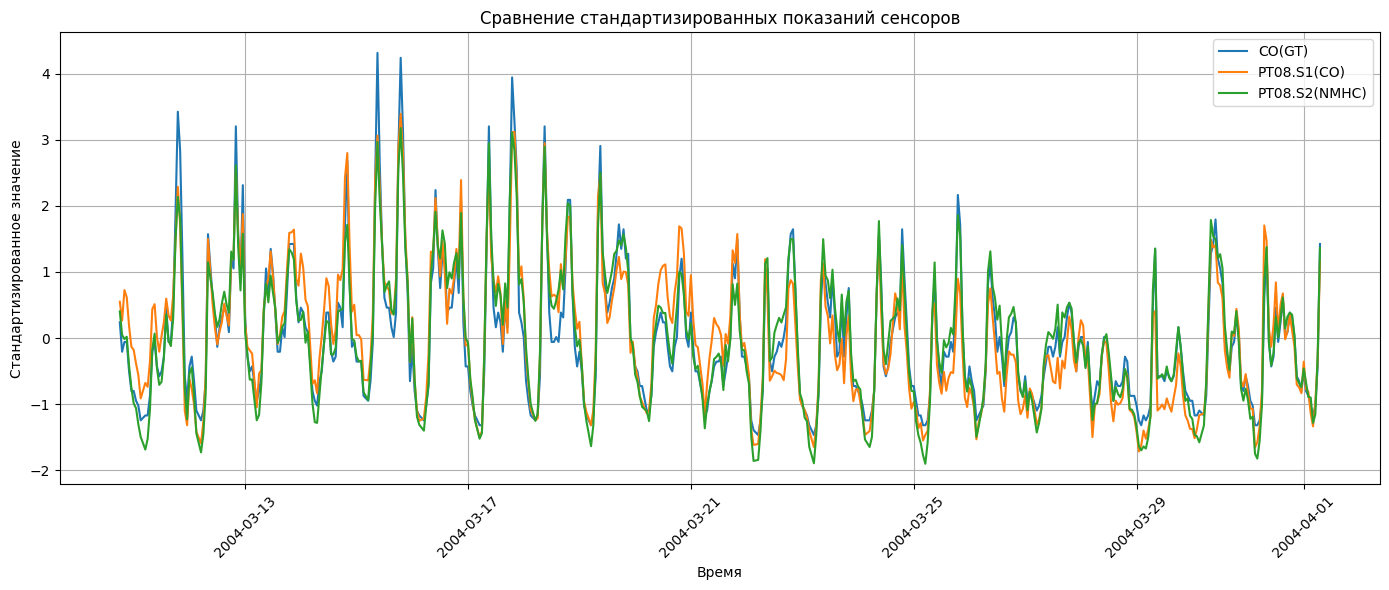

In [15]:
def zscore(x):
    x = fill_series(x)
    return (x - np.mean(x)) / np.std(x)


plt.figure(figsize=(14, 6))

for col in ["CO(GT)", "PT08.S1(CO)", "PT08.S2(NMHC)"]:
    if col in aq_small.columns:
        plt.plot(aq_small["Date_Time"], zscore(aq_small[col]), linewidth=1.5, label=col)

plt.title("Сравнение стандартизированных показаний сенсоров")
plt.xlabel("Время")
plt.ylabel("Стандартизированное значение")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Стандартизированные ряды сенсоров имеют похожую динамику изменений во времени.
Пики и спады у CO(GT), PT08.S1(CO) и PT08.S2(NMHC) происходят почти одновременно,
что подтверждает высокую корреляцию между датчиками и их чувствительность к одним и тем же изменениям качества воздуха

### 9.2. Корреляции внешнего датасета

,CO(GT),PT08.S1(CO),PT08.S2(NMHC),T,RH
CO(GT),1.000000,0.929417,0.963596,0.314926,-0.199573
PT08.S1(CO),0.929417,1.000000,0.928332,0.377333,-0.156564
PT08.S2(NMHC),0.963596,0.928332,1.000000,0.423480,-0.287635
T,0.314926,0.377333,0.423480,1.000000,-0.815327
RH,-0.199573,-0.156564,-0.287635,-0.815327,1.000000


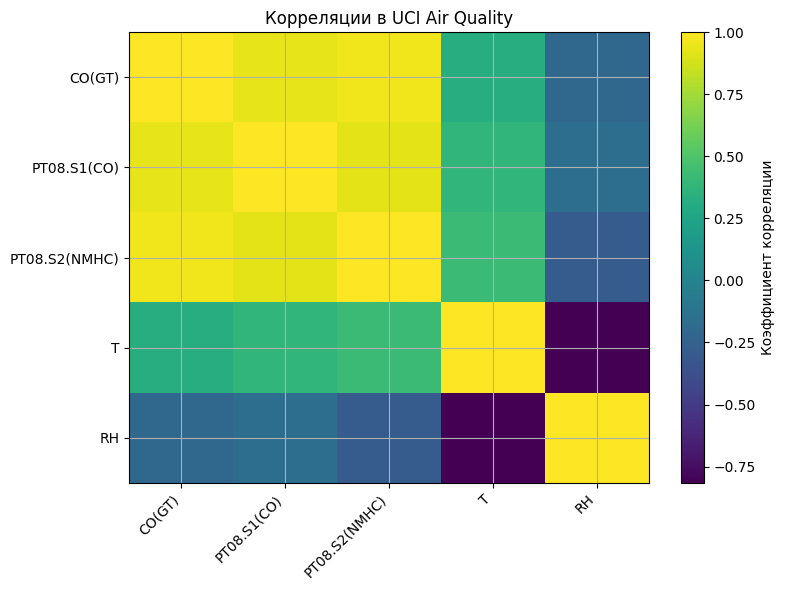

In [16]:
aq_corr = aq_small.drop(columns=["Date_Time"]).corr()

display(aq_corr)

plt.figure(figsize=(8, 6))
plt.imshow(aq_corr, aspect="auto")
plt.colorbar(label="Коэффициент корреляции")
plt.xticks(range(len(aq_corr.columns)), aq_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(aq_corr.index)), aq_corr.index)
plt.title("Корреляции в UCI Air Quality")
plt.tight_layout()
plt.show()

Между сенсорами CO(GT), PT08.S1(CO) и PT08.S2(NMHC) наблюдается высокая положительная корреляция,
что говорит о схожем изменении показателей загрязнения воздуха.
Температура имеет умеренную положительную связь с газовыми показателями,
а влажность RH показывает отрицательную корреляцию, особенно с температурой


### 9.3. Фильтрация одного сенсорного ряда

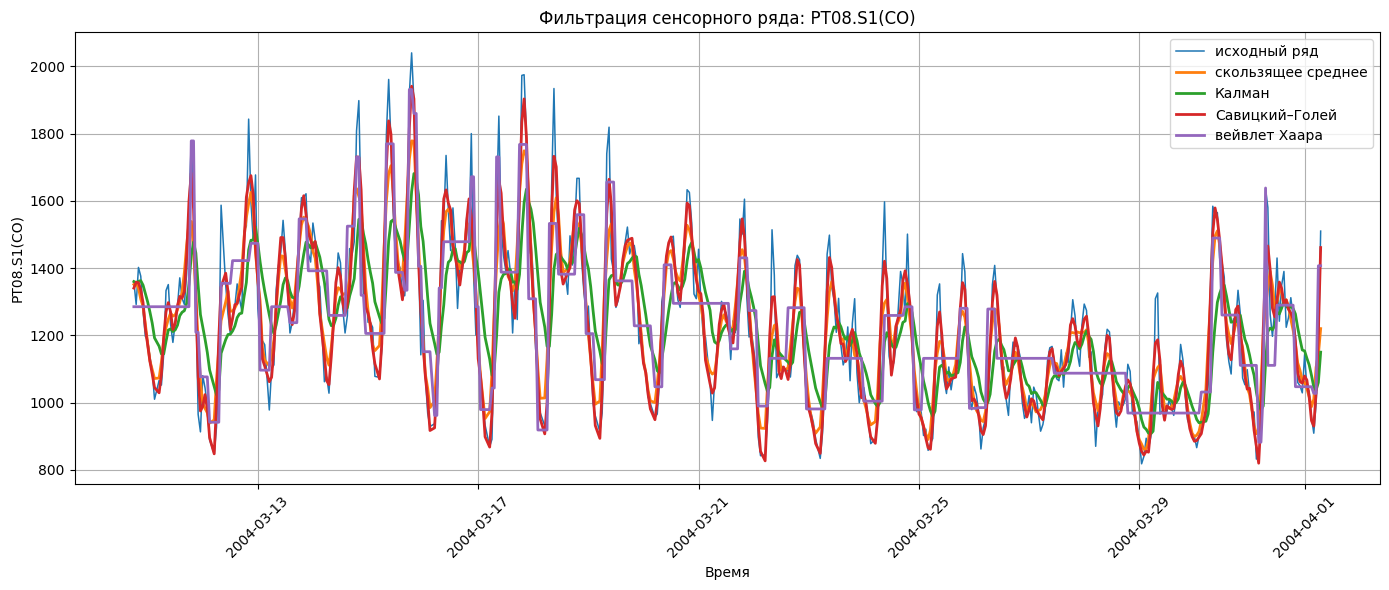

In [17]:
sensor_col = "PT08.S1(CO)" if "PT08.S1(CO)" in aq_small.columns else aq_small.columns[1]

sensor_filtered = apply_all_filters(aq_small[sensor_col])
sensor_filtered.insert(0, "Date_Time", aq_small["Date_Time"])

plt.figure(figsize=(14, 6))
plt.plot(sensor_filtered["Date_Time"], sensor_filtered["исходный ряд"], linewidth=1.1, label="исходный ряд")

for method in ["скользящее среднее", "Калман", "Савицкий–Голей", "вейвлет Хаара"]:
    plt.plot(sensor_filtered["Date_Time"], sensor_filtered[method], linewidth=2, label=method)

plt.title(f"Фильтрация сенсорного ряда: {sensor_col}")
plt.xlabel("Время")
plt.ylabel(sensor_col)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

На графике видно, что все методы фильтрации уменьшают шум и сглаживают сенсорный ряд.
Фильтр Калмана дает наиболее плавный результат, а фильтр Савицкого–Голея лучше сохраняет форму исходных колебаний.
Вейвлет Хаара также снижает шум, но делает сигнал более ступенчатым.

### 9.4. Вывод по хард-свободе

In [18]:
print("ВЫВОД ПО ВНЕШНЕМУ ДАТАСЕТУ")
print("-" * 70)
print(f"Источник данных: {aq_source}.")
print("Внешний набор содержит несколько сенсорных временных рядов, поэтому подходит для анализа данных с несколькими датчиками.")

if "CO(GT)" in aq_corr.columns and "PT08.S1(CO)" in aq_corr.index:
    print(f"Корреляция CO(GT) и PT08.S1(CO): {aq_corr.loc['PT08.S1(CO)', 'CO(GT)']:.3f}")

if "CO(GT)" in aq_corr.columns and "PT08.S2(NMHC)" in aq_corr.index:
    print(f"Корреляция CO(GT) и PT08.S2(NMHC): {aq_corr.loc['PT08.S2(NMHC)', 'CO(GT)']:.3f}")

print("После фильтрации сенсорный ряд становится более гладким: уменьшаются случайные резкие колебания,")
print("а общая форма изменения во времени сохраняется. Это полезно для мониторинга, где отдельные шумовые выбросы")
print("могут мешать увидеть реальную динамику показателя.")

ВЫВОД ПО ВНЕШНЕМУ ДАТАСЕТУ
----------------------------------------------------------------------
Источник данных: UCI Air Quality.
Внешний набор содержит несколько сенсорных временных рядов, поэтому подходит для анализа данных с несколькими датчиками.
Корреляция CO(GT) и PT08.S1(CO): 0.929
Корреляция CO(GT) и PT08.S2(NMHC): 0.964
После фильтрации сенсорный ряд становится более гладким: уменьшаются случайные резкие колебания,
а общая форма изменения во времени сохраняется. Это полезно для мониторинга, где отдельные шумовые выбросы
могут мешать увидеть реальную динамику показателя.


# Общий итог

были реализованы и применены четыре подхода к фильтрации временных рядов:

- скользящее среднее;
- фильтр Калмана;
- фильтр Савицкого–Голея;
- вейвлет-фильтрация Хаара.

На данных варианта 21 было показано, что фильтры уменьшают резкие колебания и помогают увидеть общий тренд.  
По корреляционному анализу можно определить, какие товары сильнее связаны с прибылью.  
Спектральный анализ и автокорреляция позволяют искать возможную повторяемость, но из-за длины ряда всего 50 дней выводы о периодичности нужно делать осторожно.

В хард-части использован внешний датасет с несколькими сенсорами качества воздуха. На нём показано, что методы фильтрации также применимы не только к продажам, но и к данным физических датчиков.